In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('./data/santander_train.csv', encoding='latin-1')

print(df.shape)
df.head()

(76020, 371)


,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,1,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.170000,0
1,3,2,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.030000,0
2,4,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.770000,0
3,8,2,37,0.0,195.0,195.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64007.970000,0
4,10,2,39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117310.979016,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76020 entries, 0 to 76019
Columns: 371 entries, ID to TARGET
dtypes: float64(111), int64(260)
memory usage: 215.2 MB


In [6]:
print(df['TARGET'].value_counts())

TARGET
0    73012
1     3008
Name: count, dtype: int64


In [8]:
unsatified_cnt = df[df['TARGET'] == 1].TARGET.count()
total_cnt = df.TARGET.count()
print(unsatified_cnt, total_cnt)
print(unsatified_cnt/total_cnt)

3008 76020
0.0395685345961589


In [9]:
df.describe()

,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
count,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,...,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,7.602000e+04,76020.000000
mean,75964.050723,-1523.199277,33.212865,86.208265,72.363067,119.529632,3.559130,6.472698,0.412946,0.567352,...,7.935824,1.365146,12.215580,8.784074,31.505324,1.858575,76.026165,56.614351,1.172358e+05,0.039569
std,43781.947379,39033.462364,12.956486,1614.757313,339.315831,546.266294,93.155749,153.737066,30.604864,36.513513,...,455.887218,113.959637,783.207399,538.439211,2013.125393,147.786584,4040.337842,2852.579397,1.826646e+05,0.194945
min,1.000000,-999999.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.163750e+03,0.000000
25%,38104.750000,2.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.787061e+04,0.000000
50%,76043.000000,2.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.064092e+05,0.000000
75%,113748.750000,2.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.187563e+05,0.000000
max,151838.000000,238.000000,105.000000,210000.000000,12888.030000,21024.810000,8237.820000,11073.570000,6600.000000,6600.000000,...,50003.880000,20385.720000,138831.630000,91778.730000,438329.220000,24650.010000,681462.900000,397884.300000,2.203474e+07,1.000000


In [10]:
df['var3'].value_counts()

var3
 2         74165
 8           138
-999999      116
 9           110
 3           108
           ...  
 63            1
 194           1
 40            1
 57            1
 87            1
Name: count, Length: 208, dtype: int64

In [11]:
df['var3'].replace(-999999,2,inplace=True)
df.drop('ID',axis=1,inplace=True)

In [12]:
df.head()

,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,imp_op_var40_ult1,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.170000,0
1,2,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.030000,0
2,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.770000,0
3,2,37,0.0,195.0,195.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64007.970000,0
4,2,39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117310.979016,0


In [13]:
X_features = df.iloc[:,:-1]
y_label = df.iloc[:,-1]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size=0.1, random_state=42)

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=42)

In [19]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

xgb_clf = XGBClassifier(n_estimators=400, 
                        learning_rate=0.05,
                        random_state=42,
                        early_stopping_rounds =50,
                        eval_metric = 'auc'
                        )

xgb_clf.fit(X_tr, y_tr,eval_set = [(X_tr, y_tr),(X_val,y_val)]);

[0]	validation_0-auc:0.84292	validation_1-auc:0.82079
[1]	validation_0-auc:0.84719	validation_1-auc:0.82165
[2]	validation_0-auc:0.84907	validation_1-auc:0.82305
[3]	validation_0-auc:0.85045	validation_1-auc:0.82450
[4]	validation_0-auc:0.85177	validation_1-auc:0.82721
[5]	validation_0-auc:0.85408	validation_1-auc:0.82923
[6]	validation_0-auc:0.85533	validation_1-auc:0.83053
[7]	validation_0-auc:0.85696	validation_1-auc:0.83088
[8]	validation_0-auc:0.85773	validation_1-auc:0.83133
[9]	validation_0-auc:0.85869	validation_1-auc:0.83273
[10]	validation_0-auc:0.85951	validation_1-auc:0.83365
[11]	validation_0-auc:0.86128	validation_1-auc:0.83492
[12]	validation_0-auc:0.86167	validation_1-auc:0.83557
[13]	validation_0-auc:0.86256	validation_1-auc:0.83563
[14]	validation_0-auc:0.86331	validation_1-auc:0.83572
[15]	validation_0-auc:0.86398	validation_1-auc:0.83633
[16]	validation_0-auc:0.86463	validation_1-auc:0.83625
[17]	validation_0-auc:0.86520	validation_1-auc:0.83668
[18]	validation_0-au

In [20]:
xgb_roc_auc = roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:,1])
print(xgb_roc_auc)

0.843833198603345


In [21]:
from hyperopt import hp

xgb_search_space = {
    'max_depth' : hp.quniform('max_depth',5,15,1),
    'min_child_weight' : hp.quniform('min_child_weight',1,6,1),
    'colsample_bytree' : hp.quniform('colsample_bytree',0.5,0.95,0.05),
    'learning_rate' : hp.quniform('learning_rate',0.01,0.2,0.01)
}

In [27]:
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score

def objective_func(search_space):
    xgb_clf = XGBClassifier(n_estimators = 400,
                            max_depth=int(search_space['max_depth']),
                            min_child_weight = int(search_space['min_child_weight']),
                            colsample_bytree = search_space['colsample_bytree'],
                            learning_rate = search_space['learning_rate'],
                            early_stopping_rounds = 30,
                            eval_metric = 'auc')
    roc_auc_lists = []

    kf = KFold(n_splits = 3)

    for tr_index, val_index in kf.split(X_train):
        X_tr, y_tr = X_train.iloc[tr_index], y_train.iloc[tr_index]
        X_val, y_val = X_train.iloc[val_index], y_train.iloc[val_index]

        xgb_clf.fit(X_tr, y_tr,
                    eval_set = [(X_tr, y_tr), (X_val,y_val)])

        score = roc_auc_score(y_val, xgb_clf.predict_proba(X_val)[:,1])
        roc_auc_lists.append(score)
    return -1 * np.mean(roc_auc_lists)

In [28]:
from hyperopt import fmin, tpe, Trials

trials = Trials()

best = fmin(fn = objective_func,
             space = xgb_search_space,
             algo = tpe.suggest,
             max_evals= 50,
             trials= trials,
             rstate=np.random.default_rng(seed = 30))

print(best)

[0]	validation_0-auc:0.84769	validation_1-auc:0.81099 
[1]	validation_0-auc:0.85258	validation_1-auc:0.81217 
[2]	validation_0-auc:0.85681	validation_1-auc:0.81808 
[3]	validation_0-auc:0.85926	validation_1-auc:0.82051 
[4]	validation_0-auc:0.86085	validation_1-auc:0.82203 
[5]	validation_0-auc:0.86158	validation_1-auc:0.82220 
[6]	validation_0-auc:0.86219	validation_1-auc:0.82255 
[7]	validation_0-auc:0.86433	validation_1-auc:0.82320 
[8]	validation_0-auc:0.86606	validation_1-auc:0.82399 
[9]	validation_0-auc:0.86829	validation_1-auc:0.82354 
[10]	validation_0-auc:0.86887	validation_1-auc:0.82257
[11]	validation_0-auc:0.86915	validation_1-auc:0.82053
[12]	validation_0-auc:0.87064	validation_1-auc:0.82183
[13]	validation_0-auc:0.87153	validation_1-auc:0.82225
[14]	validation_0-auc:0.87285	validation_1-auc:0.82298
[15]	validation_0-auc:0.87379	validation_1-auc:0.82332
[16]	validation_0-auc:0.87474	validation_1-auc:0.82402
[17]	validation_0-auc:0.87567	validation_1-auc:0.82455
[18]	valid

In [29]:
xgb_clf = XGBClassifier(n_estimators = 400,
                        learning_rate = round(best['learning_rate'],5),
                        max_depth = int(best['max_depth']),
                        min_child_weight = int(best['min_child_weight']),
                        colsample_bytree = round(best['colsample_bytree'],5),
                        early_stopping_rounds = 50,
                        eval_metric = 'auc')

xgb_clf.fit(X_tr, y_tr,
            eval_set = [(X_tr,y_tr),(X_val,y_val)])

xgb_roc_auc = roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:,1])
print(xgb_roc_auc)

[0]	validation_0-auc:0.83750	validation_1-auc:0.82452
[1]	validation_0-auc:0.84482	validation_1-auc:0.82785
[2]	validation_0-auc:0.84710	validation_1-auc:0.83044
[3]	validation_0-auc:0.84875	validation_1-auc:0.83084
[4]	validation_0-auc:0.84978	validation_1-auc:0.82972
[5]	validation_0-auc:0.85142	validation_1-auc:0.83301
[6]	validation_0-auc:0.85259	validation_1-auc:0.83459
[7]	validation_0-auc:0.85455	validation_1-auc:0.83491
[8]	validation_0-auc:0.85596	validation_1-auc:0.83601
[9]	validation_0-auc:0.85630	validation_1-auc:0.83607
[10]	validation_0-auc:0.85674	validation_1-auc:0.83542
[11]	validation_0-auc:0.85678	validation_1-auc:0.83632
[12]	validation_0-auc:0.85785	validation_1-auc:0.83673
[13]	validation_0-auc:0.85849	validation_1-auc:0.83751
[14]	validation_0-auc:0.85866	validation_1-auc:0.83811
[15]	validation_0-auc:0.85965	validation_1-auc:0.83889
[16]	validation_0-auc:0.86009	validation_1-auc:0.83897
[17]	validation_0-auc:0.86047	validation_1-auc:0.83934
[18]	validation_0-au

In [36]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

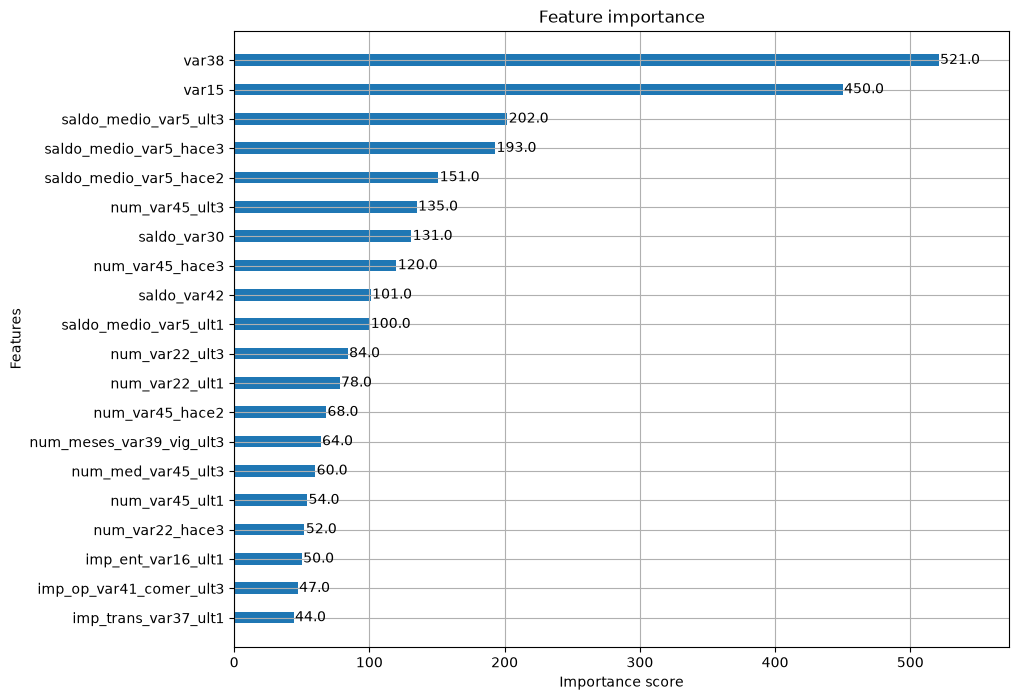

In [38]:


fig, ax = plt.subplots(1,1,figsize=(10,8))
plot_importance(xgb_clf, ax=ax, max_num_features=20, height=0.4)

In [35]:
from lightgbm import LGBMClassifier

lgbm_clf = LGBMClassifier(n_estimators= 500)
eval_set = [(X_tr,y_tr),(X_val,y_val)]
lgbm_clf.fit(X_tr,y_tr,
             eval_metric='auc',
             eval_set = eval_set)

lgbm_roc_auc = roc_auc_score(y_test, lgbm_clf.predict_proba(X_test)[:,1])

print(lgbm_roc_auc)

0.8093448331008979


In [39]:
lgbm_search_space={
    'num_leaves': hp.quniform('num_leaves',32,64,1),
    'max_depth':hp.quniform('max_depth',100,160,1),
    'min_child_samples':hp.quniform('min_child_samples',60,100,1),
    'subsample':hp.quniform('subsample',0.7,1,0.1),
    'learning_rate':hp.quniform('learning_rate',0.01,0.2,0.01)
}

In [47]:
def objective_func(search_space):
    lgbm_clf = LGBMClassifier(n_estimators=100,
                              max_depth=int(search_space['max_depth']),
                              num_leaves=int(search_space['num_leaves']),
                              min_child_samples=int(search_space['min_child_samples']),
                              subsample = search_space['subsample'],
                              learning_rate=search_space['learning_rate'],
                              early_stopping_rounds = 30,
                              eval_metric= 'auc')

    roc_auc_lists = []
    kf = KFold(n_splits = 3)

    for tr_index, val_index in kf.split(X_train):
        X_tr, y_tr = X_train.iloc[tr_index], y_train.iloc[tr_index]
        X_val, y_val = X_train.iloc[val_index], y_train.iloc[val_index]

        lgbm_clf.fit(X_tr, y_tr, 
                     eval_set= [(X_tr,y_tr), (X_val,y_val)])

        score = roc_auc_score(y_val, lgbm_clf.predict_proba(X_val)[:,1])
        roc_auc_lists.append(score)

        return -1 * np.mean(roc_auc_lists)

In [48]:
from hyperopt import fmin, tpe, Trials

trials = Trials()

best = fmin(fn = objective_func,
            space = lgbm_search_space,
            trials=trials,
            max_evals=50,
            algo=tpe.suggest,
            rstate=np.random.default_rng(seed=30)
            )

print(best)

Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:       
[100]	training's binary_logloss: 0.125017	valid_1's binary_logloss: 0.138695
Training until validation scores don't improve for 30 rounds                     
Early stopping, best iteration is:                                               
[19]	training's binary_logloss: 0.118032	valid_1's binary_logloss: 0.139489
Training until validation scores don't improve for 30 rounds                     
Early stopping, best iteration is:                                               
[49]	training's binary_logloss: 0.116885	valid_1's binary_logloss: 0.138283
Training until validation scores don't improve for 30 rounds                     
Early stopping, best iteration is:                                               
[26]	training's binary_logloss: 0.115514	valid_1's binary_logloss: 0.13917
Training until validation scores don't improve for 30 rounds                     
Early 

In [50]:
lgbm_clf = LGBMClassifier(n_estimators=100,
                              max_depth=int(best['max_depth']),
                              num_leaves=int(best['num_leaves']),
                              min_child_samples=int(best['min_child_samples']),
                              subsample = best['subsample'],
                              learning_rate=best['learning_rate'],
                              early_stopping_rounds = 100,
                              eval_metric= 'auc')

lgbm_clf.fit(X_tr,y_tr,eval_set=[(X_tr,y_tr),(X_val,y_val)])

lgbm_roc_auc = roc_auc_score(y_test, lgbm_clf.predict_proba(X_test)[:,1])
print(lgbm_roc_auc)

Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[100]	training's binary_logloss: 0.127265	valid_1's binary_logloss: 0.135033
0.8400280283744757
